# Cluster HFpEF

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn

import rpy2
print(rpy2.__version__)

from IPython.display import display

3.4.5


In [2]:
df = pd.read_excel('HFpEF-research_100.xlsx', skiprows=[1,2,3,4,5,6])

## Clean Data

In [3]:
df = df.drop(columns=['Unnamed: 0', 'time to mortality after diagnosis', 'time to HF hospitalization after diagnosis'])

In [5]:
df.columns

Index(['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'smoke', 'BMI', 'DM', 'Insulin',
       'AF', 'SBP', 'DBP', 'MAP', 'PP', 'HR', 'ACE-i', 'ARB', 'ARNI',
       'betablocker', 'Aspirin', 'SGLT2i', 'MRA', 'MI', 'stroke', 'COPD',
       'NYHA', 'edema', 'SSRI', 'Death', 'CV death', 'HF hospitalization',
       'NTProBNP', 'medial a'', 'medial E'', 'lateral E'', 'e/E'',
       'lateral e/E'', 'E/A', 'Mitral E/e'', 'TR Vmax', 'RWT', 'LV mass index',
       'LAVI', 'LA diameter', 'LVEF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 100 non-null    int64  
 1   Sex                 100 non-null    int64  
 2   Cr                  100 non-null    float64
 3   GFR                 100 non-null    float64
 4   CKD stage           100 non-null    int64  
 5   smoke               13 non-null     float64
 6   BMI                 80 non-null     float64
 7   DM                  100 non-null    int64  
 8   Insulin             100 non-null    int64  
 9   AF                  100 non-null    int64  
 10  SBP                 98 non-null     float64
 11  DBP                 98 non-null     float64
 12  MAP                 100 non-null    float64
 13  PP                  100 non-null    int64  
 14  HR                  97 non-null     float64
 15  ACE-i               100 non-null    int64  
 16  ARB      

In [7]:
df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,DM,Insulin,AF,...,e/E',lateral e/E',E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LAVI,LA diameter,LVEF
count,100.000000,100.000000,100.000000,100.000000,100.000000,13.0,80.000000,100.000000,100.000000,100.000000,...,90.000000,92.000000,79.000000,94.000000,69.000000,96.000000,96.000000,61.000000,61.000000,100.000000
mean,72.170000,1.670000,1.778700,50.722200,2.850000,1.0,25.865000,0.590000,0.310000,0.360000,...,15.669611,13.811196,0.993723,17.751383,2.862754,0.727375,120.398854,43.660656,4.205902,62.038000
std,11.581991,0.472582,1.557726,26.622537,1.095215,0.0,5.819524,0.494311,0.464823,0.482418,...,6.067683,5.636383,0.623157,7.015630,0.704648,0.401205,48.500832,19.450975,0.693951,7.249393
min,34.000000,1.000000,0.550000,2.000000,1.000000,1.0,16.600000,0.000000,0.000000,0.000000,...,6.450000,3.900000,0.400000,4.290000,0.690000,0.177000,47.400000,9.500000,2.600000,50.000000
25%,65.000000,1.000000,0.897500,26.750000,2.000000,1.0,21.825000,0.000000,0.000000,0.000000,...,10.975000,9.325000,0.600000,12.425000,2.540000,0.440000,88.525000,30.900000,3.700000,55.875000
50%,74.000000,2.000000,1.170000,52.000000,3.000000,1.0,24.650000,1.000000,0.000000,0.000000,...,14.925000,13.100000,0.890000,16.450000,2.810000,0.605000,115.350000,39.500000,4.200000,61.250000
75%,79.250000,2.000000,2.000000,68.250000,4.000000,1.0,29.325000,1.000000,1.000000,1.000000,...,19.037500,16.650000,1.200000,21.500000,3.160000,0.925000,141.305000,53.200000,4.600000,67.100000
max,97.000000,2.000000,10.000000,105.000000,5.000000,1.0,45.000000,1.000000,1.000000,1.000000,...,33.750000,30.700000,4.100000,42.200000,4.550000,2.300000,356.600000,107.700000,6.000000,80.000000


In [8]:
# df['smoke'] = df['smoke'].fillna(0)
# df['BMI'] = df['BMI'].fillna(0)
# df['SBP'] = df['SBP'].fillna(0)
# df['DBP'] = df['DBP'].fillna(0)
# df['HR'] = df['HR'].fillna(0)
# df['stroke'] = df['stroke'].fillna(0)
df = df.copy()
df = df.dropna(subset=['SBP', 'DBP'])
df.loc[df['NTProBNP']=='>35,000','NTProBNP'] = 35001
df.loc[df['NTProBNP']=='> 35000','NTProBNP'] = 35001
df['NTProBNP'] = df['NTProBNP'].astype('float')

df = df.fillna(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98 entries, 0 to 99
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 98 non-null     int64  
 1   Sex                 98 non-null     int64  
 2   Cr                  98 non-null     float64
 3   GFR                 98 non-null     float64
 4   CKD stage           98 non-null     int64  
 5   smoke               98 non-null     float64
 6   BMI                 98 non-null     float64
 7   DM                  98 non-null     int64  
 8   Insulin             98 non-null     int64  
 9   AF                  98 non-null     int64  
 10  SBP                 98 non-null     float64
 11  DBP                 98 non-null     float64
 12  MAP                 98 non-null     float64
 13  PP                  98 non-null     int64  
 14  HR                  98 non-null     float64
 15  ACE-i               98 non-null     int64  
 16  ARB       

In [10]:
df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,DM,Insulin,AF,...,e/E',lateral e/E',E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LAVI,LA diameter,LVEF
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,71.959184,1.663265,1.785408,50.869592,2.846939,0.132653,21.114286,0.581633,0.316327,0.367347,...,14.155561,12.738469,0.782552,16.743163,2.015612,0.698551,115.998878,27.176531,2.545612,62.105102
std,11.604228,0.475023,1.570997,26.728925,1.096875,0.340943,11.354485,0.495827,0.467433,0.484561,...,7.488935,6.640708,0.691967,8.067268,1.439859,0.422547,53.494470,26.203525,2.147586,7.225176
min,34.000000,1.000000,0.550000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000
25%,65.000000,1.000000,0.892500,27.250000,2.000000,0.000000,18.700000,0.000000,0.000000,0.000000,...,9.812500,8.625000,0.500000,11.800000,0.000000,0.432500,85.075000,0.000000,0.000000,56.000000
50%,74.000000,2.000000,1.170000,52.000000,3.000000,0.000000,23.300000,1.000000,0.000000,0.000000,...,13.615000,12.150000,0.700000,16.300000,2.575000,0.580000,113.850000,28.050000,3.600000,61.250000
75%,79.000000,2.000000,1.982500,68.750000,4.000000,0.000000,28.475000,1.000000,1.000000,1.000000,...,18.825000,16.575000,1.000000,20.850000,3.040000,0.900000,138.905000,44.725000,4.400000,67.300000
max,97.000000,2.000000,10.000000,105.000000,5.000000,1.000000,45.000000,1.000000,1.000000,1.000000,...,33.750000,30.700000,4.100000,42.200000,4.550000,2.300000,356.600000,107.700000,6.000000,80.000000


In [ ]:
df_data = df.rename(columns={s:s.replace(' ', '_').replace("'","") for s in df.columns})
# df_data

## All Features

In [12]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from sklearn.metrics.cluster import silhouette_score, davies_bouldin_score
from sklearn.metrics.cluster import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.cluster import calinski_harabasz_score, homogeneity_completeness_v_measure
from sklearn.metrics.cluster import contingency_matrix, rand_score, mutual_info_score
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score

In [13]:
lbl_colname= ['Death', 'CV_death', 'HF_hospitalization']

y = np.array(df_data[lbl_colname])#.ravel()

X = df_data.drop(lbl_colname, axis = 1)
# Saving feature names for later use
feature_list = list(X.columns)
# # Convert to numpy array
X = np.array(X)

In [15]:
def get_score(k, X, y_true, y_pred):
    _, counts = np.unique(y_pred, return_counts=True)
    
    sil = silhouette_score(X, y_pred)
    db = davies_bouldin_score(X, y_pred)
    hom = homogeneity_score(y_true, y_pred)
    com = completeness_score(y_true, y_pred)
    vms = v_measure_score(y_true, y_pred)
    cal = calinski_harabasz_score(X, y_pred)
    rand = rand_score(y_true, y_pred)
    mi = mutual_info_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    ar = adjusted_rand_score(y_true, y_pred)
    cmat = contingency_matrix(y_true, y_pred)
    return k, sil, db, hom, com, vms, cal, rand, mi, ami, ar, cmat, counts

In [16]:
from rpy2.robjects.packages import importr, data
from rpy2.robjects import IntVector, Formula
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# import R's "base" package
base = importr('base')

# import R's "utils" package
utils = importr('utils')

stats = importr('stats')

# import R's "utils" package
polca = importr('poLCA')

In [ ]:
with localconverter(ro.default_converter + pandas2ri.converter):
    r_from_pd_df = ro.conversion.py2rpy(df_data.round()+1)

# r_from_pd_df

In [18]:
df_data.columns

Index(['Age', 'Sex', 'Cr', 'GFR', 'CKD_stage', 'smoke', 'BMI', 'DM', 'Insulin',
       'AF', 'SBP', 'DBP', 'MAP', 'PP', 'HR', 'ACE-i', 'ARB', 'ARNI',
       'betablocker', 'Aspirin', 'SGLT2i', 'MRA', 'MI', 'stroke', 'COPD',
       'NYHA', 'edema', 'SSRI', 'Death', 'CV_death', 'HF_hospitalization',
       'NTProBNP', 'medial_a', 'medial_E', 'lateral_E', 'e/E', 'lateral_e/E',
       'E/A', 'Mitral_E/e', 'TR_Vmax', 'RWT', 'LV_mass_index', 'LAVI',
       'LA_diameter', 'LVEF'],
      dtype='object')

In [19]:
(df_data+1).describe()

,Age,Sex,Cr,GFR,CKD_stage,smoke,BMI,DM,Insulin,AF,...,e/E,lateral_e/E,E/A,Mitral_E/e,TR_Vmax,RWT,LV_mass_index,LAVI,LA_diameter,LVEF
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,72.959184,2.663265,2.785408,51.869592,3.846939,1.132653,22.114286,1.581633,1.316327,1.367347,...,15.155561,13.738469,1.782552,17.743163,3.015612,1.698551,116.998878,28.176531,3.545612,63.105102
std,11.604228,0.475023,1.570997,26.728925,1.096875,0.340943,11.354485,0.495827,0.467433,0.484561,...,7.488935,6.640708,0.691967,8.067268,1.439859,0.422547,53.494470,26.203525,2.147586,7.225176
min,35.000000,2.000000,1.550000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,51.000000
25%,66.000000,2.000000,1.892500,28.250000,3.000000,1.000000,19.700000,1.000000,1.000000,1.000000,...,10.812500,9.625000,1.500000,12.800000,1.000000,1.432500,86.075000,1.000000,1.000000,57.000000
50%,75.000000,3.000000,2.170000,53.000000,4.000000,1.000000,24.300000,2.000000,1.000000,1.000000,...,14.615000,13.150000,1.700000,17.300000,3.575000,1.580000,114.850000,29.050000,4.600000,62.250000
75%,80.000000,3.000000,2.982500,69.750000,5.000000,1.000000,29.475000,2.000000,2.000000,2.000000,...,19.825000,17.575000,2.000000,21.850000,4.040000,1.900000,139.905000,45.725000,5.400000,68.300000
max,98.000000,3.000000,11.000000,106.000000,6.000000,2.000000,46.000000,2.000000,2.000000,2.000000,...,34.750000,31.700000,5.100000,43.200000,5.550000,3.300000,357.600000,108.700000,7.000000,81.000000


In [20]:
# x_var = ",".join(['Age', 'Sex', 'Cr', 'GFR', 'CKD_stage', 'AF', 'MAP', 'PP', 'NTProBNP', "medial_a", "medial_E", 'LAVI', 'LA_diameter'])
x_var = ",".join(['Age', 'Sex', 'Cr', 'GFR', "medial_E", 'LAVI', 'LA_diameter'])
s = f"cbind({x_var})~Death"
fmla = Formula(s)
fmla

<rpy2.robjects.Formula object at 0x000002636248B900> [RTYPES.LANGSXP]
R classes: ('formula',)

In [21]:
p = []
for k in range(2,8):
    p.append(polca.poLCA(fmla, r_from_pd_df, nclass=k))

Conditional item response (column) probabilities,
 by outcome variable, for each class (row) 
 
$Age
          Pr(1) Pr(2) Pr(3) Pr(4) Pr(5) Pr(6) Pr(7) Pr(8) Pr(9) Pr(10) Pr(11)
class 1:      0     0     0     0     0     0     0     0     0      0      0
class 2:      0     0     0     0     0     0     0     0     0      0      0
          Pr(12) Pr(13) Pr(14) Pr(15) Pr(16) Pr(17) Pr(18) Pr(19) Pr(20) Pr(21)
class 1:       0      0      0      0      0      0      0      0      0      0
class 2:       0      0      0      0      0      0      0      0      0      0
          Pr(22) Pr(23) Pr(24) Pr(25) Pr(26) Pr(27) Pr(28) Pr(29) Pr(30) Pr(31)
class 1:       0      0      0      0      0      0      0      0      0      0
class 2:       0      0      0      0      0      0      0      0      0      0
          Pr(32) Pr(33) Pr(34) Pr(35) Pr(36) Pr(37) Pr(38) Pr(39) Pr(40) Pr(41)
class 1:       0      0      0 0.0000      0      0      0      0      0      0
class 2:       0      0  

In [22]:
# p = polca.poLCA(fmla, r_from_pd_df, nclass=2)

In [23]:
# for i,j in p.items():
#     print(i,j)

In [24]:
# type(p[p.names.index('predclass')])

In [25]:
# vector = np.array(p[p.names.index('predclass')])

In [26]:
# vector

In [44]:
dfs = []
for i in range(y.shape[1]):
    df = pd.DataFrame([get_score(k, X, y[:,i], np.array(m[m.names.index('predclass')])) for k, m in zip(range(2, 8),p)],
                      columns=['k', 'silhouette',
                               'davies', 'homogeneity',
                               'completeness', 'vmeasure', 
                               'calinski', 'rand index', 
                               'mutual info', 'ami', 'adjusted rand', 
                               'contingency matrix', 'counts'])
    dfs.append(df)


In [45]:
np.array(p[5][p[5].names.index('predclass')])

array([7, 3, 7, 3, 7, 3, 7, 3, 3, 3, 7, 3, 7, 3, 3, 3, 3, 7, 3, 3, 7, 3,
       3, 3, 3, 7, 7, 3, 3, 3, 3, 3, 3, 7, 7, 3, 3, 3, 3, 3, 7, 7, 3, 7,
       7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 7, 3, 3, 3, 3, 3, 3, 3, 3, 7,
       7, 3, 3, 3, 3, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 3, 3,
       3, 7, 3, 3, 3, 7, 3, 3, 3, 3], dtype=int32)

In [46]:
y[:,0]

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

In [47]:
# all_dfs = []
# for f in [get_sc_pred, get_km_pred, get_gm_pred]:
#     dfs = []
#     for i in range(y.shape[1]):
#         df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, 12)],
#                           columns=['k', 'silhouette',
#                                    'davies', 'homogeneity',
#                                    'completeness', 'vmeasure', 
#                                    'calinski', 'rand index', 
#                                    'mutual info', 'ami', 'adjusted rand', 
#                                    'contingency matrix', 'counts'])
#         dfs.append(df)
#     all_dfs.append(dfs)

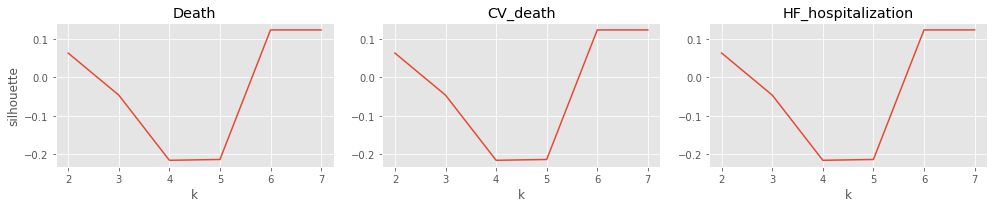

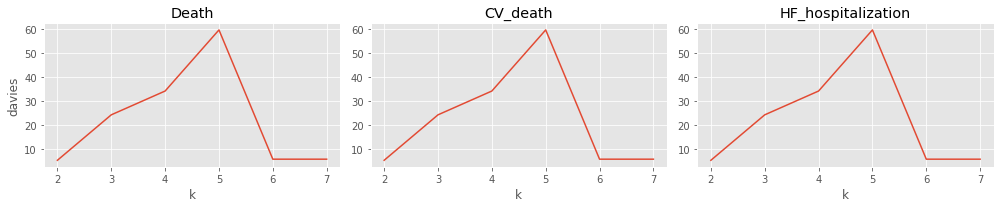

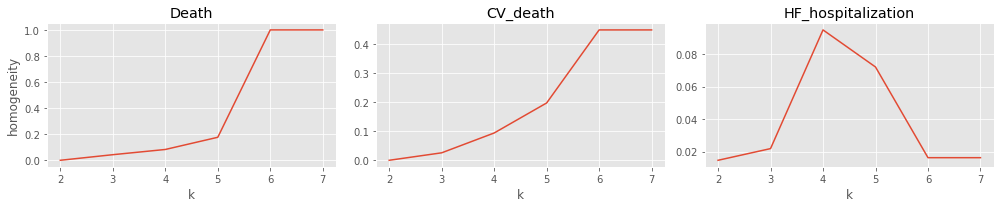

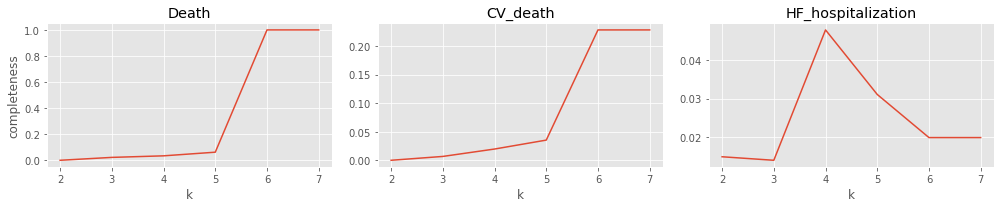

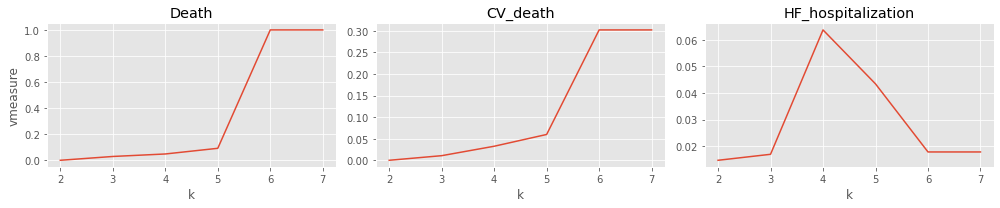

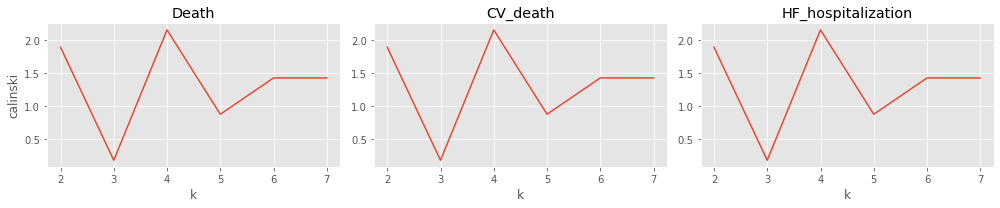

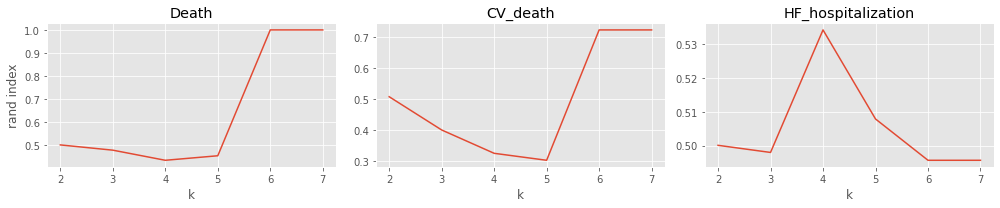

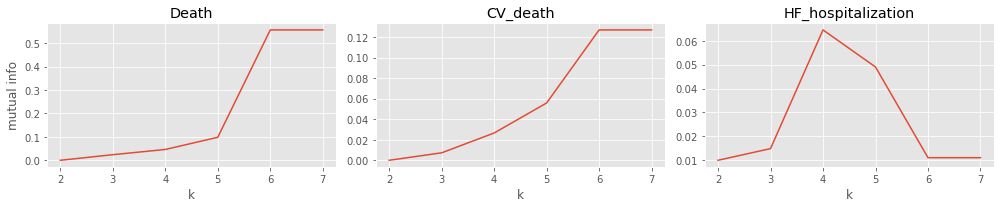

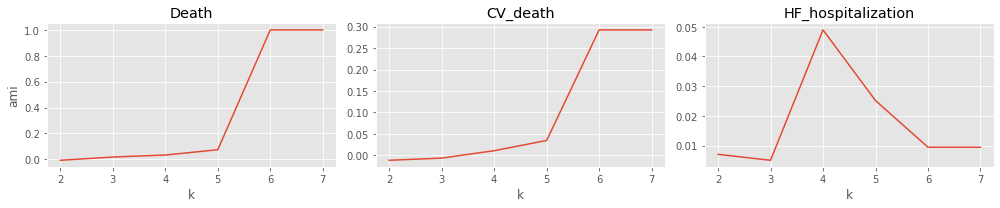

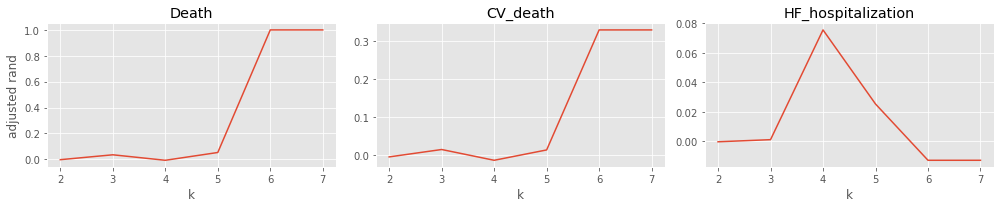

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('ggplot')

methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

y1 = 'vmeasure'
x = 'k'

for y1 in ['silhouette', 'davies', 'homogeneity', 'completeness', 'vmeasure', 'calinski', 'rand index', 'mutual info', 'ami', 'adjusted rand']:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for i, lbl in enumerate(lbl_colname):
        axes[i].plot(dfs[i][x], dfs[i][y1])
        axes[i].set_title(f'{lbl}')
        axes[i].set_xlabel(x)
        axes[i].tick_params(axis='y')
    axes[0].set_ylabel(y1)
    plt.tight_layout()


The meaning of the scores.
<!-- * `BIC` lower is better
* `AIC` lower is better -->
* `silhouette` higher is better
* `davies` lower is better
* `homogeneity` higher is better
* `completeness` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `rand index` higher is better
* `mutual info` higher is better

In [54]:
dfs[0]['contingency matrix']

0                       [[45, 29], [14, 10]]
1                 [[35, 14, 25], [8, 10, 6]]
2          [[16, 21, 16, 21], [3, 4, 2, 15]]
3    [[10, 18, 8, 13, 25], [3, 1, 8, 10, 2]]
4                         [[0, 74], [24, 0]]
5                         [[74, 0], [0, 24]]
Name: contingency matrix, dtype: object

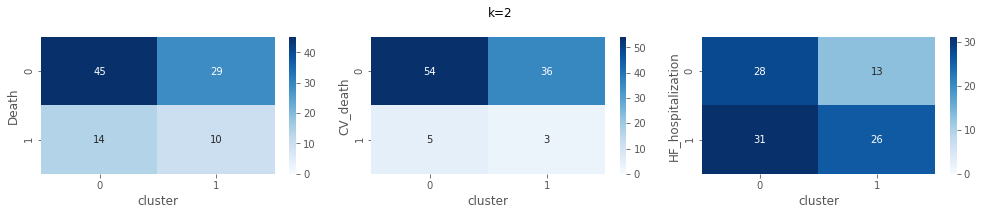

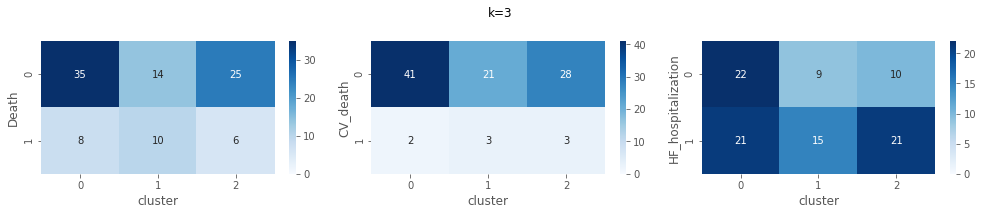

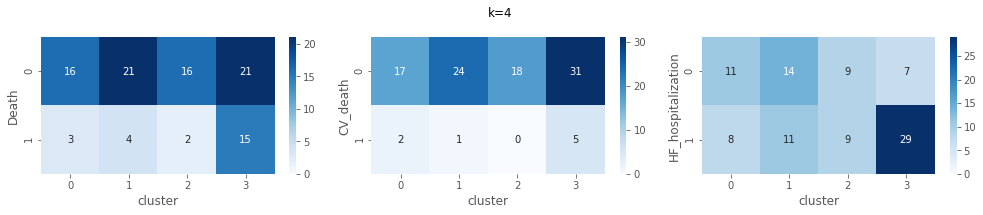

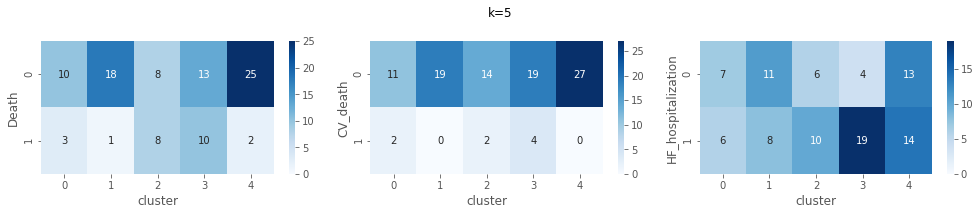

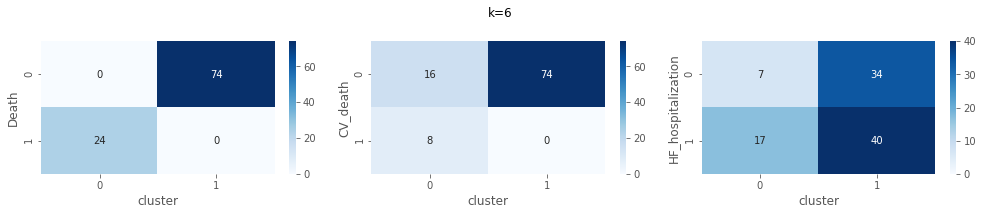

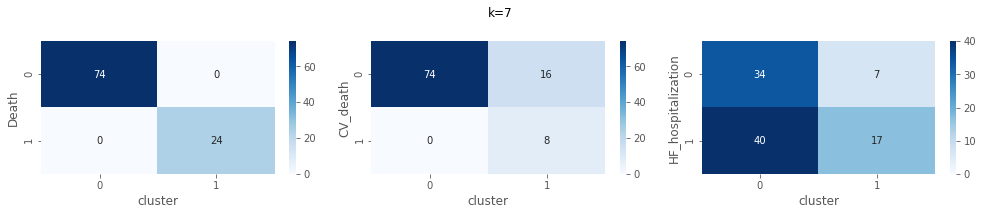

In [53]:
n = len(dfs[0]['contingency matrix'])
for l in range(n):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    fig.suptitle(f"k={dfs[0]['k'][l]}")
    for i, lbl in enumerate(lbl_colname):
#         for l, t in enumerate(all_dfs[j][i]['contingency matrix']):
        t = dfs[i]['contingency matrix'][l]
        df_cm = pd.DataFrame(t, 
                  index = np.arange(t.shape[0]),
                  columns = np.arange(t.shape[1]))
        res = sn.heatmap(df_cm, annot=True, vmin=0.0, cmap="Blues", ax=axes[i])
        res.set_ylabel(lbl)
        res.set_xlabel('cluster')
    plt.tight_layout()

In [ ]:
# for i, lbl in enumerate(lbl_colname):
#     display(lbl)
#     for j, met in enumerate(methods):
#         display(met)
#         display(all_dfs[j][i])

### BIC and AIC Gaussian Mixture

In [ ]:
# bics = []
# aics = []
# for nc in range(2,12):
#     gm = GaussianMixture(n_components=nc, random_state=0, init_params='kmeans').fit(X)
#     y_pred = gm.predict(X)
#     bics.append(gm.bic(X))
#     aics.append(gm.aic(X))

In [ ]:
# import matplotlib.pyplot as plt

In [ ]:
# plt.plot(range(2,12), bics)
# plt.plot(range(2,12), aics)
# plt.xlabel('# clusters')
# plt.legend(['bic','aic'])
# plt.title('GMM BIC and AIC')
# plt.show()

In [ ]:
# min(bics), min(aics)

## Our Feature

In [ ]:
lbl_colname= ['Death', 'CV death', 'HF hospitalization']

y = np.array(data[lbl_colname])#.ravel()

X = data.drop(lbl_colname, axis = 1)
X = X[['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'AF', 'MAP', 'PP', 'NTProBNP', "medial a'", "medial E'", 'LAVI', 'LA diameter']]
print(X)
# Saving feature names for later use
feature_list = list(X.columns)
# # Convert to numpy array
X = np.array(X)

### BIC and AIC Gaussian Mixture

In [ ]:
# bics = []
# aics = []
# for nc in range(2,12):
#     gm = GaussianMixture(n_components=nc, random_state=0, init_params='kmeans').fit(X)
#     y_pred = gm.predict(X)
#     bics.append(gm.bic(X))
#     aics.append(gm.aic(X))

In [ ]:
# plt.plot(range(2,12), bics)
# plt.plot(range(2,12), aics)
# plt.legend(['bic','aic'])
# plt.show()

In [ ]:
# min(bics), min(aics)

In [ ]:
# all_dfs = []
# for f in [get_sc_pred, get_km_pred, get_gm_pred]:
#     dfs = []
#     for i in range(y.shape[1]):
#         df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, 12)],
#                           columns=['k', 'silhouette',
#                                    'davies', 'homogeneity',
#                                    'completeness', 'vmeasure', 
#                                    'calinski', 'rand index', 
#                                    'mutual info', 'ami', 'adjusted rand', 
#                                    'contingency matrix', 'counts'])
#         dfs.append(df)
#     all_dfs.append(dfs)

In [ ]:
# %matplotlib inline
# import matplotlib.pyplot as plt

# plt.style.use('ggplot')

# methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

# y1 = 'vmeasure'
# x = 'k'

# for y1 in ['silhouette', 'davies', 'homogeneity', 'completeness', 'vmeasure', 'calinski', 'rand index', 'mutual info', 'ami', 'adjusted rand']:
#     fig, axes = plt.subplots(1, 3, figsize=(14, 3))
#     for i, lbl in enumerate(lbl_colname):
#         for j, met in enumerate(methods):
#             axes[i].plot(all_dfs[j][i][x], all_dfs[j][i][y1], label=met)
#         axes[i].set_title(f'{lbl}')
#         axes[i].set_xlabel(x)
#         axes[i].tick_params(axis='y')
#     axes[0].legend()
#     axes[0].set_ylabel(y1)
#     plt.tight_layout()

In [ ]:
# for j, met in enumerate(methods):
#     n = len(all_dfs[j][i]['contingency matrix'])
#     for l in range(n):
#         fig, axes = plt.subplots(1, 3, figsize=(14, 3))
#         fig.suptitle(f"{met}, k={all_dfs[j][0]['k'][l]}")
#         for i, lbl in enumerate(lbl_colname):
#     #         for l, t in enumerate(all_dfs[j][i]['contingency matrix']):
#             t = all_dfs[j][i]['contingency matrix'][l]
#             df_cm = pd.DataFrame(t, 
#                       index = np.arange(t.shape[0]),
#                       columns = np.arange(t.shape[1]))
#             res = sn.heatmap(df_cm, annot=True, vmin=0.0, cmap="Blues", ax=axes[i])
#             res.set_ylabel(lbl)
#             res.set_xlabel('cluster')
#         plt.tight_layout()